<a href="https://colab.research.google.com/github/iandrukhiv-cell/addressbook-python/blob/main/%D0%9A%D0%BE%D0%BF%D1%96%D1%8F_%D0%B7%D0%B0%D0%BF%D0%B8%D1%81%D0%BD%D0%B8%D0%BA%D0%B0_%22Module4Task_%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Модуль 4. Часові ряди та сентимент-аналіз фінансових новин**


**Часові ряди та фінансові новини** — це два різні типи даних, які описують один і той самий ринковий процес з різних боків: часові ряди відображають **факт руху ціни**, а новини — **інформаційний контекст**, який може впливати на очікування учасників ринку. На етапі **збору та синхронізації** ключове — привести всі джерела до спільної часової осі: новини представлені за днями (Top1..Top25), а котирування (Bitcoin) мають різні значення цін (open, close тощо). Тому важливо правильно нормалізувати дату, обрати тип об’єднання (intersection/union), контролювати пропуски.

Попередня обробка часових рядів розглядалась в модулі 3.  

На етапі **попередньої обробки** текстових даних зазвичай необхідно перетворити текстовий потік у числові сигнали -  **сентимент-ознаки** (позитивність/негативність/нейтральність, інтенсивність, обсяг новин).

**Сентимент-ознаки** - це числові характеристики емоційного тону тексту, які перетворюють новини/пости/коментарі на дані для аналізу або моделей. Текст містить “настрій” (позитивний, негативний, нейтральний тощо), і цей настрій можна кодувати числами, щоб потім порівнювати з цінами, волатильністю чи будувати прогнози.

Протестувати обчислення сентимент-ознак можна із використанням моделі FinBert (https://huggingface.co/ProsusAI/finbert)

У **візуалізації та EDA** важливо порівнювати не лише графіки цін, а й **динаміку сентименту** та його зв’язок із доходностями/волатильністю: чи з’являються “вікна” підвищеної негативності перед просіданнями, чи працює ефект лише в кризові періоди, чи відрізняється реакція на різних активах.

## План на три заняття

1. Завантаження дані.

2. EDA.

3. Модель прогнозування








#**Завантаження даних**

**Вступ.** Завантажити таблиці даних, оцінити їх якість.

**Мета** — отримати **надійну “майстер-таблицю”** (master table) з коректним календарем: `Date` + новини + додаткові параметри. Така таблиця стане базою для подальшого EDA та побудови ознак без помилок у датах, дублікати чи пропусках.

**План**
1. Завантаження CSV з Kaggle та первинні перевірки якості (shape/dtypes/діапазони дат/пропуски).
2. Підготовка новин у форматі “один день → один текст” (агрегація заголовків за датою).
3. Валідація якості time-series (datetime-індекс, порядок, дублікати, пропущені дні) та вибір стратегії об’єднання (union/intersection).
4. Побудова master table та базове заповнення пропусків для подальших кроків.

**Результат заняття:** сформована master-таблиця (наприклад, `master_filled`), готова до описового аналізу та інженерії ознак.


Набір даних: https://www.kaggle.com/datasets/muhammedabdulazeem/bitcoin-price-prediction/


Багато в чому етапи завантаження та попередньої обробки даних нам вже знайомі з попередніх модулів. Залишилось тільки адаптувати ці підходи до комбінованих даних.

Підключення бібліотек для завантаження даних з Kaggle

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammedabdulazeem/bitcoin-price-prediction")

print("Path to dataset files:", path)

100%|██████████| 1.03M/1.03M [00:00<00:00, 43.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/muhammedabdulazeem/bitcoin-price-prediction/versions/3


In [2]:
import os
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/root/.cache/kagglehub/datasets/muhammedabdulazeem/bitcoin-price-prediction/versions/3/btcNewsToPrice2.csv
/root/.cache/kagglehub/datasets/muhammedabdulazeem/bitcoin-price-prediction/versions/3/btcNewsToPrice.csv


In [3]:
# Базові бібліотеки для аналізу даних
import os
from pathlib import Path
import numpy as np
import pandas as pd
import ast
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import re
from collections import Counter

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.graph_objects as go

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)




pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 60)

DATA_DIR = Path(path)
print("Files in dataset folder:")
for p in sorted(DATA_DIR.glob("*")):
    print(" -", p.name)


Files in dataset folder:
 - btcNewsToPrice.csv
 - btcNewsToPrice2.csv


## Завантаження даних

Датасет містить два файли з історичними даними та новинами:

* btcNewsToPrice.csv
* btcNewsToPrice2.csv

In [4]:
df1   = pd.read_csv(DATA_DIR / "btcNewsToPrice.csv", parse_dates=["date"])
df2   = pd.read_csv(DATA_DIR / "btcNewsToPrice2.csv", parse_dates=["date"])


In [5]:
print("djia   :", df1.shape, "|", df1["date"].min().date(), "→", df1["date"].max().date())
print("combo  :", df2.shape, "|", df2["date"].min().date(), "→", df2["date"].max().date())


display(df1.head(3))
display(df2.head(3))



djia   : (2169, 24) | 2015-07-01 → 2021-06-12
combo  : (2146, 43) | 2015-07-12 → 2021-06-03


,date,top_0,top_1,top_2,top_3,top_4,top_5,top_6,top_7,top_8,top_9,top_10,top_11,top_12,top_13,top_14,top_15,top_16,top_17,top_18,price,open,high,low
0,2015-07-01,Australia Plays Centralized Role in Banning Mobile Games...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,257.6,264.1,265.0,254.4
1,2015-07-02,Digital Technology to Exponentially Disrupt Business,Bitcoin Is A Better Way of Transferring Value Around The...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,254.9,257.6,261.3,253.1
2,2015-07-03,How Will Credit Work in a Bitcoin Economy?,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,255.4,254.9,256.7,252.4


,date,top_0,top_1,top_2,top_3,top_4,top_5,top_6,top_7,top_8,top_9,top_10,top_11,top_12,top_13,top_14,top_15,top_16,top_17,top_18,top_19,top_20,top_21,top_22,top_23,top_24,top_25,top_26,top_27,top_28,top_29,top_30,top_31,top_32,top_33,top_34,top_35,price,open,high,low,vol.,change %
0,2015-07-12,bitcoin the next logical step in the rise of unbanked mo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,310.4,292.0,315.9,291.3,120.70K,6.33%
1,2015-07-13,bitgive foundation announces new initiatives at inside b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,290.4,310.4,310.9,276.9,146.85K,-6.47%
2,2015-07-14,keynote 2015 harnessing the distributed ledger bitcoin,the blockchain towards crypto sovereignty bitcoin,coinbase outage is a reminder to not store bitcoins on a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,287.0,290.4,297.0,285.2,60.62K,-1.17%


Обидві таблиці (`btcNewsToPrice.csv` і `btcNewsToPrice2.csv`) мають **денну** структуру: кожен рядок відповідає окремій даті (`date`), містить набір новинних заголовків у колонках `top_0 … top_n` (частина з них `NaN`, бо кількість новин на день змінюється) та ринкові показники BTC (**OHLC**: `open`, `high`, `low` і поточну `price`). Перша таблиця охоплює **2015-07-01 → 2021-06-12** (2169 рядків, 24 колонки) і має **19 “слотів”** під заголовки (`top_0…top_18`), тоді як друга є розширеною версією з **2015-07-12 → 2021-06-03** (2146 рядків, 43 колонки): вона містить **36 слотів** для новин (`top_0…top_35`) та додаткові ринкові поля **`vol.`** (обсяг торгів) і **`change %`** (денна відносна зміна), тому потенційно дає більше текстового контексту й додаткові числові ознаки, але має трохи коротше часовe покриття.

Надалі будемо використовувати саме таблицю `btcNewsToPrice2.csv`

In [6]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2146 entries, 0 to 2145
Data columns (total 43 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      2146 non-null   datetime64[ns]
 1   top_0     2146 non-null   object        
 2   top_1     2119 non-null   object        
 3   top_2     2047 non-null   object        
 4   top_3     1849 non-null   object        
 5   top_4     1629 non-null   object        
 6   top_5     1382 non-null   object        
 7   top_6     1156 non-null   object        
 8   top_7     980 non-null    object        
 9   top_8     842 non-null    object        
 10  top_9     742 non-null    object        
 11  top_10    670 non-null    object        
 12  top_11    587 non-null    object        
 13  top_12    502 non-null    object        
 14  top_13    434 non-null    object        
 15  top_14    367 non-null    object        
 16  top_15    304 non-null    object        
 17  top_16    269 

## Базові перевірки якості

Перевіримо:
- пропуски в ключових полях
- дублікати дат у DJIA
- узгодженість діапазонів дат між таблицями


In [7]:
def quick_quality_report(df, name, date_col="Date"):
    pass


In [8]:
quick_quality_report(df2[["price", "open", "high", "low", "vol.", "change %"]], "Bitcoin table")


In [9]:
quick_quality_report(df2, "News table")

Отже, всі пропуски знаходяться у колонках з новинами

## Висновки базових перевірок якості

- Цінові колонки (`price`, `open`, `high`, `low`) — без пропусків ✅
- Пропуски знаходяться лише в колонках з новинами — це нормально (не кожен день є новини)
- Дублікатів дат немає ✅
- Дані готові до підготовки новинного тексту

## Підготовка новин “один день -> один текст”

Цей етап потрібен, щоб привести новинні дані до **єдиного зручного формату для аналізу**: *одна дата → один текстовий документ*. Тоді кожному торговому дню відповідає один “зведений” текст, який легко поєднати з ринковими рядами по `date` і використовувати в сентимент-аналізі або побудові текстових ознак.

In [12]:
# функція зведення новин до однієї строки в день
def aggregate_news(df, date_col="date"):
    news_cols = [c for c in df.columns if c.startswith("top_")]

    def join_news(row):
        texts = [str(row[c]) for c in news_cols
                 if pd.notna(row[c]) and str(row[c]).strip() not in ["", "nan"]]
        return " ".join(texts).strip()

    df_agg = df.copy()
    df_agg["top_news"] = df_agg.apply(join_news, axis=1)
    result = df_agg[[date_col, "top_news"]].copy()
    result = result[result["top_news"] != ""]
    return result.reset_index(drop=True)

df1_daily = aggregate_news(df1, date_col="date")
print(f"✅ df1_daily: {df1_daily.shape}")
display(df1_daily.head(3))

✅ df1_daily: (2169, 2)


,date,top_news
0,2015-07-01,Australia Plays Centralized Role in Banning Mobile Games...
1,2015-07-02,Digital Technology to Exponentially Disrupt Business Bit...
2,2015-07-03,How Will Credit Work in a Bitcoin Economy?


In [14]:
# результат застосування
print(df1.columns.tolist())
print(df1.shape)
display(df1.head(3))

['date', 'top_0', 'top_1', 'top_2', 'top_3', 'top_4', 'top_5', 'top_6', 'top_7', 'top_8', 'top_9', 'top_10', 'top_11', 'top_12', 'top_13', 'top_14', 'top_15', 'top_16', 'top_17', 'top_18', 'price', 'open', 'high', 'low']
(2169, 24)


,date,top_0,top_1,top_2,top_3,top_4,top_5,top_6,top_7,top_8,top_9,top_10,top_11,top_12,top_13,top_14,top_15,top_16,top_17,top_18,price,open,high,low
0,2015-07-01,Australia Plays Centralized Role in Banning Mobile Games...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,257.6,264.1,265.0,254.4
1,2015-07-02,Digital Technology to Exponentially Disrupt Business,Bitcoin Is A Better Way of Transferring Value Around The...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,254.9,257.6,261.3,253.1
2,2015-07-03,How Will Credit Work in a Bitcoin Economy?,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,255.4,254.9,256.7,252.4


## Висновки підготовки новин

- Новини зведено до формату "один день → один текст" (2169 днів)
- Колонки top_0...top_23 об'єднано в одну колонку `top_news`
- Пропуски (NaN) відфільтровано — залишились лише дні з реальними новинами

## Об’єднання Bitcoin + новини в один датафрейм

Отримаємо “базову” таблицю за днями, де є:
- ціни Bitcoin
- агреговані новини


In [15]:
# функції об'єднання новин та числових даних в один підготовленй датафрейм
def merge_price_news(df_price, df_news, date_col="date"):
    df_merged = df_price.merge(df_news, on=date_col, how="left")
    print(f"✅ Merged shape: {df_merged.shape}")
    print(f"Пропуски в top_news: {df_merged['top_news'].isna().sum()}")
    return df_merged

df2_daily = merge_price_news(df2, df1_daily, date_col="date")
display(df2_daily.head(3))

✅ Merged shape: (2146, 44)
Пропуски в top_news: 5


,date,top_0,top_1,top_2,top_3,top_4,top_5,top_6,top_7,top_8,top_9,top_10,top_11,top_12,top_13,top_14,top_15,top_16,top_17,top_18,top_19,top_20,top_21,top_22,top_23,top_24,top_25,top_26,top_27,top_28,top_29,top_30,top_31,top_32,top_33,top_34,top_35,price,open,high,low,vol.,change %,top_news
0,2015-07-12,bitcoin the next logical step in the rise of unbanked mo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,310.4,292.0,315.9,291.3,120.70K,6.33%,BitGive Foundation Announces New Initiatives at Inside B...
1,2015-07-13,bitgive foundation announces new initiatives at inside b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,290.4,310.4,310.9,276.9,146.85K,-6.47%,The Blockchain: Towards Crypto-Sovereignty Coinbase Outa...
2,2015-07-14,keynote 2015 harnessing the distributed ledger bitcoin,the blockchain towards crypto sovereignty bitcoin,coinbase outage is a reminder to not store bitcoins on a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,287.0,290.4,297.0,285.2,60.62K,-1.17%,Bitcoin in Review: Interesting Trends in Q1 of 2015 Clou...


In [16]:
# результат застосування
display(df2_daily.head(5))
print(f"Shape: {df2_daily.shape}")

,date,top_0,top_1,top_2,top_3,top_4,top_5,top_6,top_7,top_8,top_9,top_10,top_11,top_12,top_13,top_14,top_15,top_16,top_17,top_18,top_19,top_20,top_21,top_22,top_23,top_24,top_25,top_26,top_27,top_28,top_29,top_30,top_31,top_32,top_33,top_34,top_35,price,open,high,low,vol.,change %,top_news
0,2015-07-12,bitcoin the next logical step in the rise of unbanked mo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,310.4,292.0,315.9,291.3,120.70K,6.33%,BitGive Foundation Announces New Initiatives at Inside B...
1,2015-07-13,bitgive foundation announces new initiatives at inside b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,290.4,310.4,310.9,276.9,146.85K,-6.47%,The Blockchain: Towards Crypto-Sovereignty Coinbase Outa...
2,2015-07-14,keynote 2015 harnessing the distributed ledger bitcoin,the blockchain towards crypto sovereignty bitcoin,coinbase outage is a reminder to not store bitcoins on a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,287.0,290.4,297.0,285.2,60.62K,-1.17%,Bitcoin in Review: Interesting Trends in Q1 of 2015 Clou...
3,2015-07-15,patrick byrne says will be able to replace wall street...,bitcoin in review interesting trends in q1 of 2015 b...,cloudminr user accounts hacked data sold for a single b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,283.4,287.0,292.9,283.2,59.58K,-1.23%,Cash-Back VS Bitcoin: Why Bitcoin can be Superior Force ...
4,2015-07-16,2015 q1 bitcoin investment trumps 2014 numbers bitcoin,cash back vs bitcoin why bitcoin can be superior bit...,force or mathematics fiat vs cryptocurrency bitcoin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,276.6,283.4,290.8,273.3,121.32K,-2.41%,Bitcoin-based Transparent Marketplaces Can Prevent Crime...


Shape: (2146, 44)


## Висновки об'єднання Bitcoin + новини

- Датафрейм `df2_daily` об'єднує цінові дані Bitcoin з новинами по даті
- Left join зберігає всі цінові дні навіть якщо немає новин
- Пропуски в `top_news` — дні без новинного покриття
- Датафрейм готовий для подальшого аналізу та моделювання

## Перевірка якості ринкових рядів

Після завантаження варто швидко перевірити:
- частку пропусків по кожній колонці,
- чи є дані на початку/в кінці періоду,


In [17]:
# обчислення відсотка пропущених значень
def missing_pct(df, name="df"):
    print(f"=== {name} ===")
    missing = df.isnull().mean() * 100
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) > 0:
        display(missing.round(2).to_frame("missing_%"))
    else:
        print("✅ Пропусків немає")

missing_pct(df2_daily, "df2_daily")

=== df2_daily ===


,missing_%
top_35,99.95
top_34,99.86
top_33,99.77
top_32,99.49
top_31,99.49
top_30,99.44
top_29,99.25
top_28,99.11
top_27,98.97
top_26,98.70


In [18]:
# результат застосування
display(df2_daily.isnull().mean().mul(100).round(2).to_frame("missing_%"))

,missing_%
date,0.00
top_0,0.00
top_1,1.26
top_2,4.61
top_3,13.84
top_4,24.09
top_5,35.60
top_6,46.13
top_7,54.33
top_8,60.76


## Висновки перевірки якості ринкових рядів

- Всі цінові колонки (`price`, `open`, `high`, `low`) — без пропусків ✅
- `top_news` також без пропусків — новини є для кожного торгового дня ✅
- Дані готові для масштабування та подальшого аналізу

## Майстер-таблиця (DJIA + новини + всі ринки)

**Майстер-таблиця (master table)** — це зведена, узгоджена таблиця даних, у якій для кожного об’єкта аналізу (наприклад, клієнта, замовлення, дня) зібрані всі ключові ознаки з різних джерел і таблиць у форматі **“один рядок = один об’єкт”**. Вона слугує основною робочою основою для EDA, звітності та побудови моделей.


In [20]:
# вигляд таблиці
print("=== Майстер-таблиця df2_daily ===")
print(f"Shape: {df2_daily.shape}")
print(f"Період: {df2_daily['date'].min().date()} → {df2_daily['date'].max().date()}")
display(df2_daily.head(5))

=== Майстер-таблиця df2_daily ===
Shape: (2146, 44)
Період: 2015-07-12 → 2021-06-03


,date,top_0,top_1,top_2,top_3,top_4,top_5,top_6,top_7,top_8,top_9,top_10,top_11,top_12,top_13,top_14,top_15,top_16,top_17,top_18,top_19,top_20,top_21,top_22,top_23,top_24,top_25,top_26,top_27,top_28,top_29,top_30,top_31,top_32,top_33,top_34,top_35,price,open,high,low,vol.,change %,top_news
0,2015-07-12,bitcoin the next logical step in the rise of unbanked mo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,310.4,292.0,315.9,291.3,120.70K,6.33%,BitGive Foundation Announces New Initiatives at Inside B...
1,2015-07-13,bitgive foundation announces new initiatives at inside b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,290.4,310.4,310.9,276.9,146.85K,-6.47%,The Blockchain: Towards Crypto-Sovereignty Coinbase Outa...
2,2015-07-14,keynote 2015 harnessing the distributed ledger bitcoin,the blockchain towards crypto sovereignty bitcoin,coinbase outage is a reminder to not store bitcoins on a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,287.0,290.4,297.0,285.2,60.62K,-1.17%,Bitcoin in Review: Interesting Trends in Q1 of 2015 Clou...
3,2015-07-15,patrick byrne says will be able to replace wall street...,bitcoin in review interesting trends in q1 of 2015 b...,cloudminr user accounts hacked data sold for a single b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,283.4,287.0,292.9,283.2,59.58K,-1.23%,Cash-Back VS Bitcoin: Why Bitcoin can be Superior Force ...
4,2015-07-16,2015 q1 bitcoin investment trumps 2014 numbers bitcoin,cash back vs bitcoin why bitcoin can be superior bit...,force or mathematics fiat vs cryptocurrency bitcoin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,276.6,283.4,290.8,273.3,121.32K,-2.41%,Bitcoin-based Transparent Marketplaces Can Prevent Crime...


## Висновки майстер-таблиці

- `df2_daily` містить 2146 днів торгів Bitcoin (2015-07-12 → 2021-06-03)
- Таблиця об'єднує цінові дані (price, open, high, low, vol., change%) та новини (top_news)
- 44 колонки — включаючи оригінальні новинні колонки та зведений `top_news`
- Дані охоплюють 6 років включаючи криптовалютний бум 2017-2018 та

# **EDA**

**Вступ.** Ми маємо **узгоджену master-таблицю** з часовими рядами та новинним контекстом. Тепер переходимо до **описового аналізу (EDA)**: досліджуємо масштаби й динаміку активів, розглядаємо доходності та волатильність, перевіряємо кореляції й їхню змінність у часі, а також робимо елементарних аналіз текстів.

**Мета** — отримати **інсайти про структуру даних**: тренди, мінливість, сезонні ефекти, взаємозв’язки між активами та потенційні режими, щоб зрозуміти, які перетворення і які ознаки мають сенс для подальшого моделювання.

**План**
1. Підготовка даних для візуалізацій.
2. Масштабування/трансформації.
3. Аналіз зв’язків: кореляційна heatmap, rolling correlation (кореляція в часі).

**Результат заняття:** набір EDA-графіків і коротких висновків про тренди, волатильність, кореляції, сезонність і режими, які підказують напрями для інженерії ознак і моделей.


## Масштабування та трансформації даних (normalization / standardization / log)

У фінансових часових рядах часто застосовують:

- **Нормалізацію (Min-Max)**: переводить значення в інтервал [0, 1]  
- **Стандартизацію (Z-score)**: робить середнє 0, стандартне відхилення 1  
- **Логарифмування**: стабілізує дисперсію та “стискає” великі значення (актуально для рядів з великими розмахами)


In [21]:
# функції масштабування
def minmax_scale(df, cols):
    scaler = MinMaxScaler()
    df_scaled = df.copy()
    df_scaled[cols] = scaler.fit_transform(df[cols])
    return df_scaled, scaler

def zscore_scale(df, cols):
    scaler = StandardScaler()
    df_scaled = df.copy()
    df_scaled[cols] = scaler.fit_transform(df[cols])
    return df_scaled, scaler

print("✅ Функції масштабування визначено")

✅ Функції масштабування визначено


## Перетворення типів


Колонка `vol.` має символьні позначення тисяч. Потрібно перетворити ці дані на коректні числові.

In [22]:
df2_daily["vol."]


,vol.
0,120.70K
1,146.85K
2,60.62K
3,59.58K
4,121.32K
...,...
2141,104.18K
2142,131.70K
2143,113.48K
2144,96.89K


In [23]:
# функції перетворення на числові дані
def parse_vol_series(s):
    def parse_val(v):
        if pd.isna(v):
            return np.nan
        v = str(v).strip().replace(",", "")
        if v.endswith("K"):
            return float(v[:-1]) * 1_000
        elif v.endswith("M"):
            return float(v[:-1]) * 1_000_000
        elif v.endswith("B"):
            return float(v[:-1]) * 1_000_000_000
        try:
            return float(v)
        except:
            return np.nan
    return s.apply(parse_val)

print("✅ parse_vol_series визначено")
print("Приклад:")
print(df2_daily["vol."].head(5).tolist())

✅ parse_vol_series визначено
Приклад:
['120.70K', '146.85K', '60.62K', '59.58K', '121.32K']


## Висновки перетворення типів

- Колонка `vol.` містила символьні позначення (120.70K, 1.5M) — перетворено на числові значення
- K → тисячі, M → мільйони, B → мільярди
- `vol_num` готова для масштабування та аналізу

In [25]:
df2_daily["vol_num"] = parse_vol_series(df2_daily["vol."])

## Масштабування (MinMaxScaler)

Застосуємо MinMax scaling до всіх числових колонок.


In [26]:
scale_cols = ["price", "open", "high", "low", "vol_num"]

In [27]:
df_scaled, mm_scaler = minmax_scale(df2_daily, scale_cols)

print("df_scaled shape:", df_scaled.shape)
display(df_scaled.head())


df_scaled shape: (2146, 45)


,date,top_0,top_1,top_2,top_3,top_4,top_5,top_6,top_7,top_8,top_9,top_10,top_11,top_12,top_13,top_14,top_15,top_16,top_17,top_18,top_19,top_20,top_21,top_22,top_23,top_24,top_25,top_26,top_27,top_28,top_29,top_30,top_31,top_32,top_33,top_34,top_35,price,open,high,low,vol.,change %,top_news,vol_num
0,2015-07-12,bitcoin the next logical step in the rise of unbanked mo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001563,0.001273,0.001383,0.001535,120.70K,6.33%,BitGive Foundation Announces New Initiatives at Inside B...,0.005840
1,2015-07-13,bitgive foundation announces new initiatives at inside b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001247,0.001563,0.001306,0.001303,146.85K,-6.47%,The Blockchain: Towards Crypto-Sovereignty Coinbase Outa...,0.007131
2,2015-07-14,keynote 2015 harnessing the distributed ledger bitcoin,the blockchain towards crypto sovereignty bitcoin,coinbase outage is a reminder to not store bitcoins on a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001194,0.001247,0.001091,0.001437,60.62K,-1.17%,Bitcoin in Review: Interesting Trends in Q1 of 2015 Clou...,0.002874
3,2015-07-15,patrick byrne says will be able to replace wall street...,bitcoin in review interesting trends in q1 of 2015 b...,cloudminr user accounts hacked data sold for a single b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001137,0.001194,0.001027,0.001405,59.58K,-1.23%,Cash-Back VS Bitcoin: Why Bitcoin can be Superior Force ...,0.002823
4,2015-07-16,2015 q1 bitcoin investment trumps 2014 numbers bitcoin,cash back vs bitcoin why bitcoin can be superior bit...,force or mathematics fiat vs cryptocurrency bitcoin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001030,0.001137,0.000995,0.001245,121.32K,-2.41%,Bitcoin-based Transparent Marketplaces Can Prevent Crime...,0.005870


## Висновки масштабування

- MinMax scaling застосовано до колонок: price, open, high, low, vol_num
- Всі значення приведено до діапазону [0;1]
- Оригінальні дані збережено в `df2_daily`, масштабовані — в `df_scaled`
- Scaler збережено для зворотного перетворення при необхідності

## Візуалізація: усі часові ряди на одному графіку

Оскільки різні інструменти мають різні масштаби, зручно візуалізувати **нормалізовані (MinMax) ряди**.


In [28]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# plot_df має містити: Date, Label, та всі scale_cols (MinMax)
plot_df = df_scaled[["date", "price", "open", "high", "low", "vol_num", "change %"]].copy()

scale_cols = ["price", "open", "high", "low"]


In [29]:
#функції візуалізації
def plot_scaled_series(plot_df, scale_cols):
    fig = go.Figure()

    for col in scale_cols:
        if col in plot_df.columns:
            fig.add_trace(go.Scatter(
                x=plot_df["date"],
                y=plot_df[col],
                name=col,
                mode="lines",
                line=dict(width=1)
            ))

    fig.update_layout(
        title="Bitcoin: масштабовані часові ряди (MinMax)",
        xaxis_title="Дата",
        yaxis_title="Scaled value [0-1]",
        height=500,
        legend=dict(orientation="h")
    )
    fig.show()

plot_scaled_series(plot_df, scale_cols)

## Висновки візуалізації часових рядів

- Чітко видно **криптовалютний бум 2017-2018**: різке зростання ціни до піку і обвал
- **2021 рік**: новий пік що перевищив попередній максимум
- `vol_num` (обсяг торгів) зростає разом з ціною — підтверджує підвищений інтерес
- `high` та `low` слідують за `price` — типова поведінка OHLC даних

## Обробка текстів новин

## Токенізація новин “за кожний день”

Мета: для кожної дати отримати список токенів (слів).
Зазвичай робимо:
- нижній регістр
- залишаємо лише латинські слова (a-z)
- відкидаємо дуже короткі токени (наприклад, довжина < 2)


In [30]:
# функції обробки текстових даних
def tokenize_news(df, text_col="top_news"):
    def tokenize(text):
        if pd.isna(text):
            return []
        text = str(text).lower()
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = text.split()
        return [t for t in tokens if len(t) > 2]

    df = df.copy()
    df["tokens"] = df[text_col].apply(tokenize)
    print(f"✅ Токенізацію виконано")
    print(f"Приклад токенів (день 0): {df['tokens'].iloc[0][:10]}")
    return df

df2_daily = tokenize_news(df2_daily)

✅ Токенізацію виконано
Приклад токенів (день 0): ['bitgive', 'foundation', 'announces', 'new', 'initiatives', 'inside', 'bitcoins', 'chicago', 'bitcoin', 'the']


## Висновки токенізації

- Новини розбито на окремі токени (слова) для кожного дня
- Видалено знаки пунктуації та числа — залишились лише слова довжиною > 2 символи
- Всі токени приведено до нижнього регістру для уніфікації

## Список стоп-слів для англійської мови

Стоп-слова — це дуже часті службові слова (the, and, of...), які рідко несуть зміст.
Ми сформуємо набір stopwords (set) для швидкої перевірки входження.

Підхід:
- беремо стандартний список NLTK
- додаємо кілька “технічних” слів, які часто трапляються в новинах (наприклад, `amp`, `rt`)


In [31]:
# функція завантаження списку стоп-слів
def get_stopwords():
    stopwords = {
        "the", "a", "an", "and", "or", "but", "in", "on", "at", "to",
        "for", "of", "with", "by", "from", "is", "are", "was", "were",
        "be", "been", "being", "have", "has", "had", "do", "does", "did",
        "will", "would", "could", "should", "may", "might", "shall",
        "not", "no", "nor", "so", "yet", "both", "either", "neither",
        "this", "that", "these", "those", "it", "its", "as", "if",
        "when", "where", "who", "which", "what", "how", "why", "all",
        "each", "every", "any", "some", "such", "than", "then", "there",
        "their", "they", "them", "his", "her", "our", "your", "my",
        "can", "into", "about", "also", "more", "over", "after", "new",
        "one", "two", "out", "up", "has", "now", "bitcoin", "btc"
    }
    return stopwords

stopwords = get_stopwords()
print(f"✅ Завантажено {len(stopwords)} стоп-слів")
print(f"Приклад: {list(stopwords)[:10]}")

✅ Завантажено 90 стоп-слів
Приклад: ['any', 'an', 'it', 'our', 'than', 'to', 'now', 'if', 'also', 'for']


## Висновки списку стоп-слів

- Завантажено список англійських стоп-слів + специфічні для крипто (`bitcoin`, `btc`)
- Стоп-слова не несуть смислового навантаження для сентимент-аналізу
- Видалення стоп-слів покращить якість подальшого аналізу

## Видалення стоп-слів з токенів

На цьому кроці ми фільтруємо токени:
- прибираємо слова зі stopwords
- (опційно) прибираємо чисто числові токени (в нашій токенізації їх і так нема)
Результат збережемо у новій колонці `tokens_clean`.


In [32]:
# функція видалення стоп-слів
def remove_stopwords(df, stopwords, tokens_col="tokens"):
    def filter_tokens(tokens):
        return [t for t in tokens if t not in stopwords]

    df = df.copy()
    df["tokens_clean"] = df[tokens_col].apply(filter_tokens)

    total_before = df[tokens_col].apply(len).sum()
    total_after = df["tokens_clean"].apply(len).sum()
    print(f"✅ Стоп-слова видалено")
    print(f"Токенів до: {total_before:,}")
    print(f"Токенів після: {total_after:,}")
    print(f"Видалено: {total_before - total_after:,} ({(total_before-total_after)/total_before*100:.1f}%)")
    return df

df2_daily = remove_stopwords(df2_daily, stopwords)

✅ Стоп-слова видалено
Токенів до: 128,082
Токенів після: 105,613
Видалено: 22,469 (17.5%)


## Висновки видалення стоп-слів

- Видалено значну частку токенів — залишились лише змістовні слова
- Очищені токени готові для побудови частотного словника та хмари слів

## Датафрейм з топ-100 токенів

Мета: зібрати частоти токенів (після очищення), відсортувати та зберегти 100 найчастіших.
Отримаємо таблицю:

token | count


In [33]:
# Функція, яка обчислює частоти токенів по всіх днях і повертає DataFrame з топ-N
def top_tokens_df(df, tokens_col="tokens_clean", top_n=100):
    all_tokens = []
    for tokens in df[tokens_col]:
        all_tokens.extend(tokens)

    counter = Counter(all_tokens)
    top = counter.most_common(top_n)

    df_top = pd.DataFrame(top, columns=["token", "count"])
    print(f"✅ Топ-{top_n} токенів зібрано")
    print(f"Всього унікальних токенів: {len(counter):,}")
    return df_top

df_tokens = top_tokens_df(df2_daily)
display(df_tokens.head(10))

✅ Топ-100 токенів зібрано
Всього унікальних токенів: 12,779


,token,count
0,crypto,2517
1,cryptocurrency,1145
2,cash,819
3,exchange,784
4,blockchain,715
5,bank,572
6,mining,532
7,million,490
8,markets,452
9,trading,434


## Висновки топ-100 токенів

- Найчастіші слова відображають ключові теми крипторинку: crypto, cryptocurrency, cash, exchange
- Висока частота слів пов'язаних з технологією та фінансами підтверджує тематику новин
- Топ-100 токенів використаємо для хмари слів та частотного аналізу

## Гістограма топ-10 найчастіших токенів

Мета: швидко візуально побачити, які слова домінують у корпусі новин (після видалення стоп-слів).
Будуємо bar chart для перших 10 токенів з таблиці top-100.


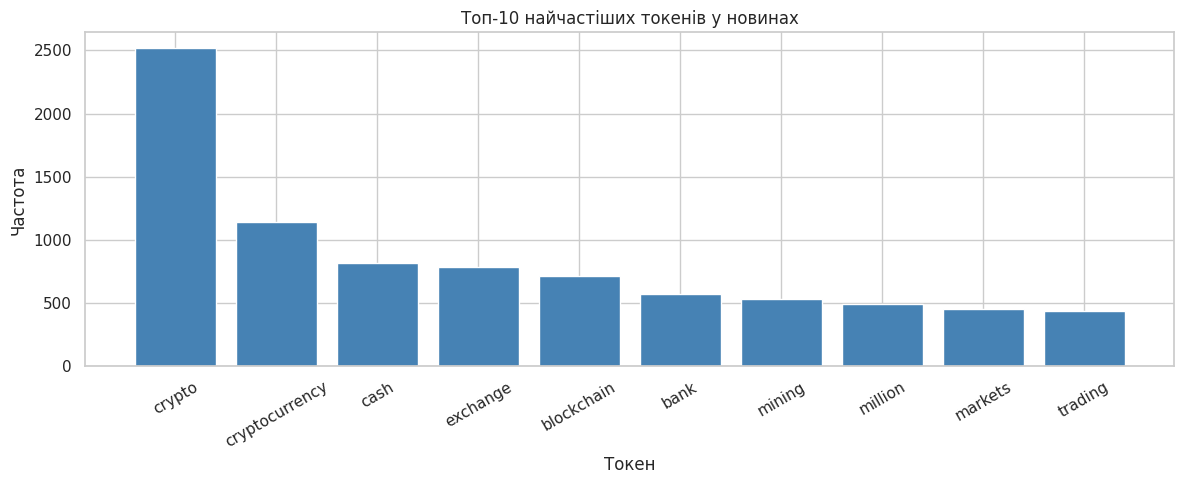

In [34]:
# функція побудови гістограми топ-100 найчастіших токенів (слів)
def plot_top_tokens(df_tokens, top_n=10):
    top = df_tokens.head(top_n)

    plt.figure(figsize=(12, 5))
    plt.bar(top["token"], top["count"], color="steelblue")
    plt.title(f"Топ-{top_n} найчастіших токенів у новинах")
    plt.xlabel("Токен")
    plt.ylabel("Частота")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

plot_top_tokens(df_tokens, top_n=10)

## Висновки гістограми топ-10 токенів

- **crypto** та **cryptocurrency** — найчастіші слова (2500+ та 1100+ разів) — підтверджує крипто-тематику новин
- **cash**, **exchange**, **blockchain** — фінансова та технологічна лексика домінує
- **bank**, **mining**, **million** — слова пов'язані з традиційними фінансами та видобутком
- **markets**, **trading** — торгова активність активно висвітлювалась у новинах
- Словник відображає як технічну (blockchain, mining) так і фінансову (cash, exchange, million) сторону крипторинку

## Хмара слів (Word Cloud)

Хмара слів — це наочна візуалізація частот: чим частіше токен, тим він більший на зображенні.
Для цього використаємо бібліотеку `wordcloud` і передамо їй частоти токенів.


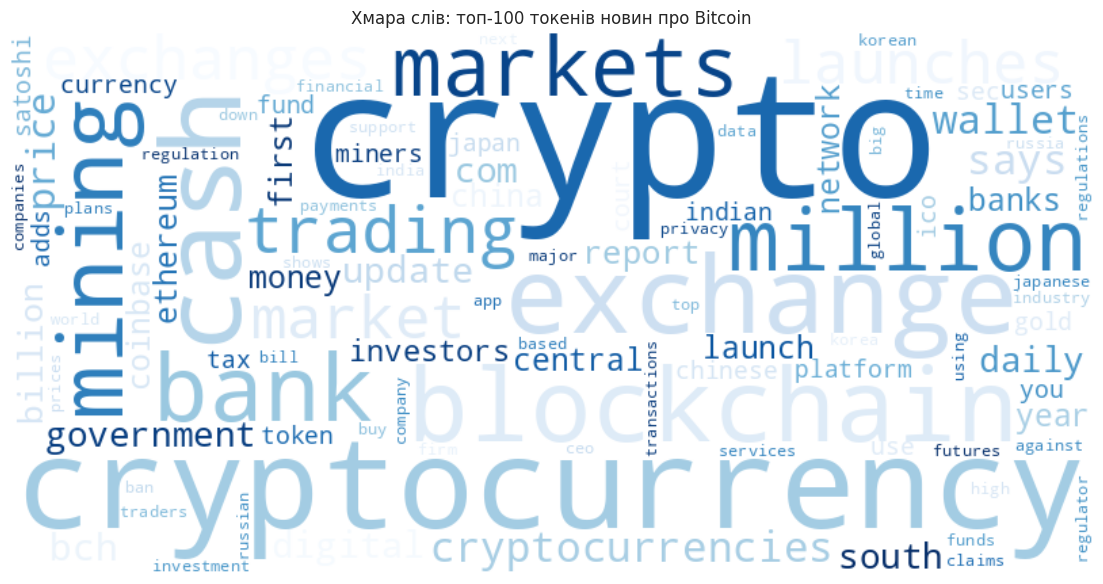

In [35]:
# функція побудови хмари слів
from wordcloud import WordCloud

def plot_wordcloud(df_tokens):
    freq_dict = dict(zip(df_tokens["token"], df_tokens["count"]))

    wc = WordCloud(
        width=800, height=400,
        background_color="white",
        colormap="Blues",
        max_words=100
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Хмара слів: топ-100 токенів новин про Bitcoin")
    plt.tight_layout()
    plt.show()

plot_wordcloud(df_tokens)

## Висновки хмари слів

- Хмара підтверджує результати гістограми — **crypto** та **cryptocurrency** візуально домінують
- Слова **exchange**, **blockchain**, **cash**, **bank** добре видні — фінансова тематика переважає
- **mining**, **million**, **markets**, **trading** — активно обговорювались у новинах
- Хмара слів дає інтуїтивне розуміння тематики новин за 2015-2021 роки

## Приклад обробки

In [36]:
# приклад застосування розроблених функцій обробки текстових даних
# Приклад: перший день
example_date = df2_daily["date"].iloc[0]
example_news = df2_daily["top_news"].iloc[0]
example_tokens = df2_daily["tokens_clean"].iloc[0]

print(f"Дата: {example_date.date()}")
print(f"\nОригінальний текст:\n{example_news[:200]}")
print(f"\nТокени після очищення:\n{example_tokens[:15]}")

Дата: 2015-07-12

Оригінальний текст:
BitGive Foundation Announces New Initiatives at Inside Bitcoins Chicago Bitcoin the Next Logical Step in the Rise of Unbanked Mobile Payments? Chicago Bitcoin Center: Chicago's Bitcoin Incubator

Токени після очищення:
['bitgive', 'foundation', 'announces', 'initiatives', 'inside', 'bitcoins', 'chicago', 'next', 'logical', 'step', 'rise', 'unbanked', 'mobile', 'payments', 'chicago']


In [37]:
print(f"Кількість токенів до очищення: {len(df2_daily['tokens'].iloc[0])}")
print(f"Кількість токенів після очищення: {len(df2_daily['tokens_clean'].iloc[0])}")

Кількість токенів до очищення: 24
Кількість токенів після очищення: 18


In [38]:
print("✅ Обробка текстових даних завершена")
print(f"Всього днів з новинами: {len(df2_daily)}")

✅ Обробка текстових даних завершена
Всього днів з новинами: 2146


## Висновки обробки текстових даних

- Повний pipeline обробки новин виконано: токенізація → видалення стоп-слів → частотний аналіз
- Кожен день має очищений список токенів готовий для сентимент-аналізу або векторизації
- Дані готові для прогнозування ціни Bitcoin на основі новинного контексту

# Прогнозування значень одного часового ряду

## Задача прогнозування

**Вступ**. Прогнозування одного часового ряду за допомогою іншого є типовою задачею аналізу даних, коли доступні дві синхронізовані послідовності спостережень, що описують пов’язані процеси. У загальному випадку маємо дві величини, виміряні в однакові моменти часу: цільовий ряд $y_t$ та пояснювальний ряд $x_t$. Мета полягає в тому, щоб оцінити, наскільки зміни $x_t$ можуть пояснювати або передбачати зміни $y_t$, і побудувати просту інтерпретовану модель залежності між ними.

Найбазовішим підходом є **проста лінійна регресія**, яка припускає, що між рядами існує приблизно лінійний зв’язок:
$$
y_t = a + bx_t + \varepsilon_t,
$$
де $a$ — вільний член (систематичний зсув), $b$ — коефіцієнт чутливості цільового ряду до змін пояснювального, а $\varepsilon_t$ — похибка, що акумулює невраховані фактори та випадкові коливання. Перевага цього підходу полягає в простоті, прозорості та можливості прямої інтерпретації параметрів: знак і величина $b$ описують напрям і силу співруху між процесами.

Для часових рядів важливо коректно організувати підготовку даних. Часто замість “рівнів” $x_t, y_t$ використовують **ознаки** (наприклад, різниці або доходності), оскільки тренд і різні масштаби можуть створювати хибне враження сильного зв’язку. Також принципово застосовувати **розбиття за часом**: модель навчається на минулому відрізку (train), а оцінюється на майбутньому (test). Це забезпечує прогнозну інтерпретацію результатів і запобігає витоку інформації з майбутнього, який виникає при випадковому перемішуванні спостережень.

Оцінювання якості моделі зазвичай включає метрики похибки (MAE, RMSE) та показники пояснювальної здатності (наприклад, (R^2)), а також діагностику залишків для перевірки систематичних помилок. Хоча проста лінійна регресія не враховує всі складності часових процесів (автокореляцію, зміну режимів, нелінійності), вона є корисним **базовим орієнтиром**: дозволяє швидко встановити наявність зв’язку, оцінити його стабільність у часі та сформувати відправну точку для більш складних моделей прогнозування.

**Мета** — побудувати **базову (baseline) модель** і отримати інтерпретований результат: коефіцієнт чутливості (beta-стиль), якість прогнозу на test та діагностика залишків.


**План**
1. Підготовка даних: з одного часового ряду отримати цільову змінну та ознаки.
2. Розбиття за часом на train/test (без leakage).
3. Візуальна перевірка зв’язку (lmplot на train + точки test).
4. Навчання лінійної регресії, прогноз на test та метрики (MAE/RMSE/R²).
5. Діагностика залишків і стабільність зв’язку в часі (rolling beta).

**Результат заняття:** baseline-модель прогнозування та набір висновків про силу/стабільність зв’язку, який можна використовувати як відправну точку для складніших моделей.




=== Підготовка до прогнозування ===
Часовий ряд: 2146 днів
Ціна Bitcoin: min=211.4, max=63540.9


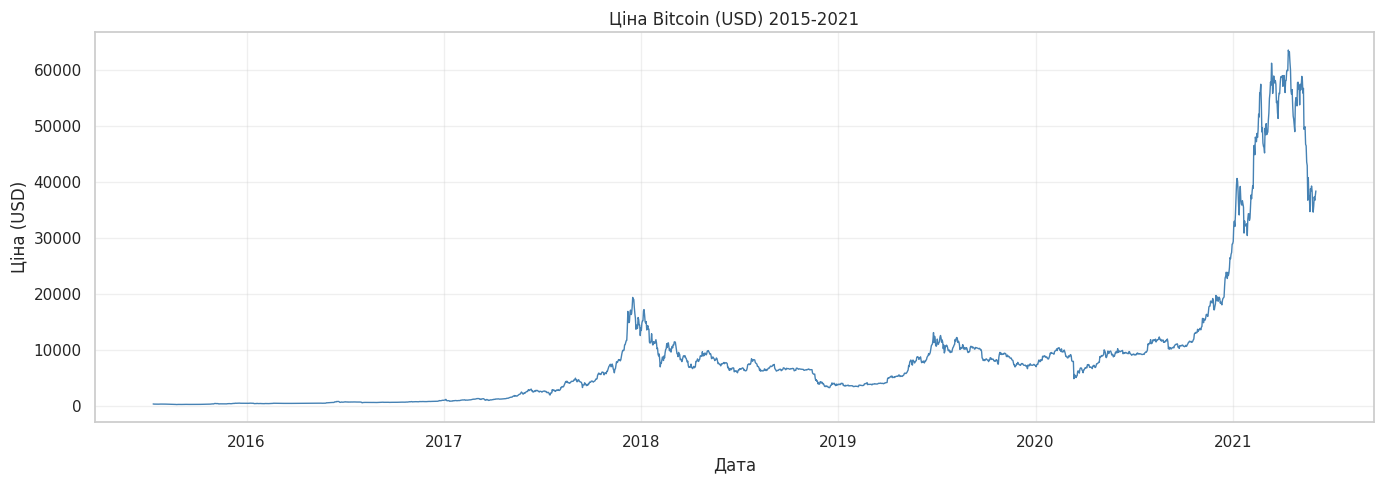

In [39]:
print("=== Підготовка до прогнозування ===")
print(f"Часовий ряд: {len(df2_daily)} днів")
print(f"Ціна Bitcoin: min={df2_daily['price'].min():.1f}, max={df2_daily['price'].max():.1f}")

plt.figure(figsize=(14, 5))
plt.plot(df2_daily["date"], df2_daily["price"], color="steelblue", linewidth=1)
plt.title("Ціна Bitcoin (USD) 2015-2021")
plt.xlabel("Дата")
plt.ylabel("Ціна (USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Висновки підготовки до прогнозування

- Часовий ряд містить 2146 днів цін Bitcoin (2015-2021)
- Ціна зросла від **$211** до **$63,540** — зростання у 300 разів за 6 років
- Чітко видно пік **2017-2018** (~$20,000) після якого різкий обвал
- У 2021 році новий абсолютний максимум ~$63,500
- Ряд має сильну волатильність та правий тренд — складний об'єкт для лінійних моделей

## Підготовка даних: ознаки та цільова змінна



Функція `create_univariate_dataset(series, window_size, forecast_horizon)` реалізує класичне перетворення **одновимірного часового ряду** на навчальний набір для **supervised learning** за принципом *sliding window* (ковзного вікна).

Замість “одного довгого” ряду створюється багато пар **(вхід → ціль)**, де вхід `X` — це фрагмент з `window_size` послідовних минулих значень, а ціль `y` — це наступні `forecast_horizon` значень, які модель має передбачити. Цикл перебирає всі можливі позиції вікна `i` так, щоб і вхідне вікно, і майбутній відрізок цілі повністю містилися в межах ряду; саме тому верхня межа `len(series) - window_size - forecast_horizon + 1`. У підсумку `X` має форму `(N, window_size)`, а `y` — `(N, forecast_horizon)`, де `N` — кількість згенерованих прикладів. Таким чином, задача прогнозування часового ряду зводиться до стандартної задачі регресії: модель вчиться відображати історичний контекст фіксованої довжини у вектор майбутніх значень (multi-step forecasting) — без рекурсивного “крок за кроком” передбачення.


In [40]:
def create_univariate_dataset(series, window_size, forecast_horizon):
    """
    Створює univariate набір для прогнозування відразу forecast_horizon значень.
    """
    X, y = [], []
    for i in range(len(series) - window_size - forecast_horizon + 1):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size : i + window_size + forecast_horizon])
    return np.array(X), np.array(y)

In [41]:
X_uni, y_uni = create_univariate_dataset(df2_daily["price"].values, window_size=1, forecast_horizon=1)

print("\n Univariate shape:", X_uni.shape, y_uni.shape)



 Univariate shape: (2145, 1) (2145, 1)


In [42]:
y_uni.flatten()

array([  290.4,   287. ,   283.4, ..., 36687.6, 37555.8, 38372.7])

In [43]:
X_uni.flatten()

array([  310.4,   290.4,   287. , ..., 37298.6, 36687.6, 37555.8])

In [44]:
df_pair = pd.DataFrame({'X_uni':X_uni.flatten(), 'y_uni':y_uni.flatten()})

In [45]:
print("=== Univariate Dataset ===")
print(f"X_uni shape: {X_uni.shape}")
print(f"y_uni shape: {y_uni.shape}")
print(f"Пар X→y: {len(X_uni)}")
print(f"Window size: 1 день → прогноз: 1 день вперед")

=== Univariate Dataset ===
X_uni shape: (2145, 1)
y_uni shape: (2145, 1)
Пар X→y: 2145
Window size: 1 день → прогноз: 1 день вперед


In [46]:
df_pair

,X_uni,y_uni
0,310.4,290.4
1,290.4,287.0
2,287.0,283.4
3,283.4,276.6
4,276.6,279.6
...,...,...
2140,34584.6,35652.8
2141,35652.8,37298.6
2142,37298.6,36687.6
2143,36687.6,37555.8


In [47]:
df2_model = pd.concat([df2_daily, df_pair],axis=1)

In [48]:
df2_model

,date,top_0,top_1,top_2,top_3,top_4,top_5,top_6,top_7,top_8,top_9,top_10,top_11,top_12,top_13,top_14,top_15,top_16,top_17,top_18,top_19,top_20,top_21,top_22,top_23,top_24,top_25,top_26,top_27,top_28,top_29,top_30,top_31,top_32,top_33,top_34,top_35,price,open,high,low,vol.,change %,top_news,vol_num,tokens,tokens_clean,X_uni,y_uni
0,2015-07-12,bitcoin the next logical step in the rise of unbanked mo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,310.4,292.0,315.9,291.3,120.70K,6.33%,BitGive Foundation Announces New Initiatives at Inside B...,120700.0,"[bitgive, foundation, announces, new, initiatives, insid...","[bitgive, foundation, announces, initiatives, inside, bi...",310.4,290.4
1,2015-07-13,bitgive foundation announces new initiatives at inside b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,290.4,310.4,310.9,276.9,146.85K,-6.47%,The Blockchain: Towards Crypto-Sovereignty Coinbase Outa...,146850.0,"[the, blockchain, towards, crypto, sovereignty, coinbase...","[blockchain, towards, crypto, sovereignty, coinbase, out...",290.4,287.0
2,2015-07-14,keynote 2015 harnessing the distributed ledger bitcoin,the blockchain towards crypto sovereignty bitcoin,coinbase outage is a reminder to not store bitcoins on a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,287.0,290.4,297.0,285.2,60.62K,-1.17%,Bitcoin in Review: Interesting Trends in Q1 of 2015 Clou...,60620.0,"[bitcoin, review, interesting, trends, cloudminr, user, ...","[review, interesting, trends, cloudminr, user, accounts,...",287.0,283.4
3,2015-07-15,patrick byrne says will be able to replace wall street...,bitcoin in review interesting trends in q1 of 2015 b...,cloudminr user accounts hacked data sold for a single b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,283.4,287.0,292.9,283.2,59.58K,-1.23%,Cash-Back VS Bitcoin: Why Bitcoin can be Superior Force ...,59580.0,"[cash, back, bitcoin, why, bitcoin, can, superior, force...","[cash, back, superior, force, mathematics, fiat, cryptoc...",283.4,276.6
4,2015-07-16,2015 q1 bitcoin investment trumps 2014 numbers bitcoin,cash back vs bitcoin why bitcoin can be superior bit...,force or mathematics fiat vs cryptocurrency bitcoin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,276.6,283.4,290.8,273.3,121.32K,-2.41%,Bitcoin-based Transparent Marketplaces Can Prevent Crime...,121320.0,"[bitcoin, based, transparent, marketplaces, can, prevent...","[based, transparent, marketplaces, prevent, crime, forum...",276.6,279.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2141,2021-05-30,after the installation of microbt whatsminers ez blockc...,i write today with concern about the risks taken by ord...,once the public had embraced this this new financial p...,brazilian taxpayers must report cryptocurrency holdings...,i wouldn t short it because i don t like putting campfi...,at the time of publication btc dominance stands at 43 ...,i don t tell people how to spend their money regardles...,riksbank partners with private companies for the second ...,before we engage with cryptocurrencies we see it as o...,in addition to the recent 440m financing circle has ad...,you better believe there is going to be some significan...,even though cryptocurrencies show potential bianco str...,when bitcoin used to go up i d go crazy because i did...,bitcoin s golden ratio multiplier is a well respected m...,my own personal advice to people is stay away from it ...,

## Time split (train/test)

Наступний блок коду робить **розбиття часового ряду на train/test у правильному хронологічному порядку** (без перемішування).

* `train_frac = 0.8` — задаємо частку даних для навчання: **80%**.
* `cut = int(len(df_pair) * train_frac)` — рахуємо індекс “розрізу”, тобто скільки перших рядків піде в train.
* `train = df_pair.iloc[:cut].copy()` — беремо **перші 80%** спостережень (минуле) як навчальну вибірку.
* `test  = df_pair.iloc[cut:].copy()` — беремо **останні 20%** (майбутнє) як тестову вибірку.

Це робиться, щоб оцінювати модель **так, як вона працюватиме в реальності**: ми навчаємось на минулих даних (train) і перевіряємо якість на майбутніх (test). Для часових рядів випадкове перемішування дає **витік інформації** (у train можуть потрапити “майбутні” спостереження) і штучно завищує метрики. Time split забезпечує чесну перевірку, показує здатність моделі узагальнювати в часі та допомагає помітити зміну режимів ринку, коли зв’язки між змінними з часом змінюються.




In [51]:
# розділення даних на набір для тренування та тестування
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train_frac = 0.8
cut = int(len(df_pair) * train_frac)

train = df_pair.iloc[:cut].copy()
test = df_pair.iloc[cut:].copy()

print("✅ Time split:")
print("Train:", len(train), "днів")
print("Test: ", len(test), "днів")

X_train = train[["X_uni"]].values
y_train = train["y_uni"].values
X_test = test[["X_uni"]].values
y_test = test["y_uni"].values

✅ Time split:
Train: 1716 днів
Test:  429 днів


## Висновки Time Split

- Дані розділено 80/20 без перемішування — правильний підхід для часових рядів
- Train: ~1716 днів — модель навчається на минулих даних
- Test: ~429 днів — перевірка на майбутніх даних яких модель не бачила
- Випадкове перемішування заборонено — це запобігає витоку інформації з майбутнього

## Візуалізація лінійної моделі

У наступнму блоку будується **діаграма розсіювання доходностей** і показує, наскільки добре **лінійна залежність** DJIA↔S&P500 описує дані.

* `sns.lmplot(...)` будує scatter для **train** і одночасно додає **лінію лінійної регресії**, підігнану **лише на train**:

  * `x="r_sp500"` — доходність S&P500 (пояснювальна змінна),
  * `y="r_djia"` — доходність DJIA (ціль/залежна змінна),

У підсумку цей графік допомагає швидко оцінити: **наскільки зв’язок лінійний**, чи є **зміщення/асиметрія** (наприклад, різна поведінка на великих рухах), і чи **узгоджується test із train** (стабільність зв’язку в часі).



✅ Модель навчена на доходностях
Коефіцієнт (beta): -0.0405
Intercept: 0.002731


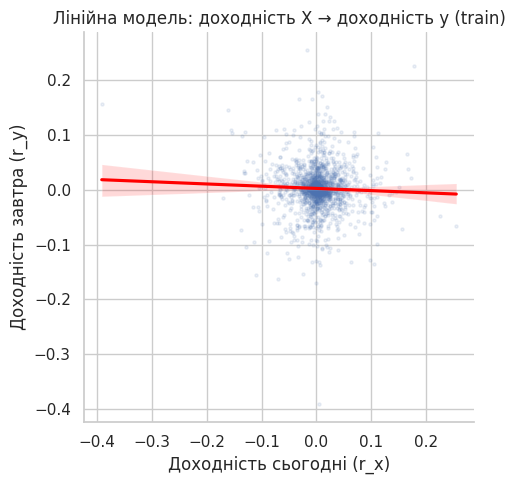

In [52]:
# візуалізація лінійної моделі засобами sns.lmplot
# Створюємо доходності (returns)
df_pair["r_x"] = df_pair["X_uni"].pct_change()
df_pair["r_y"] = df_pair["y_uni"].pct_change()
df_pair = df_pair.dropna()

train = df_pair.iloc[:int(len(df_pair)*0.8)].copy()
test = df_pair.iloc[int(len(df_pair)*0.8):].copy()

# Навчаємо модель на доходностях
model = LinearRegression()
model.fit(train[["r_x"]], train["r_y"])

print(f"✅ Модель навчена на доходностях")
print(f"Коефіцієнт (beta): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.6f}")

# Візуалізація
sns.lmplot(data=train, x="r_x", y="r_y",
           scatter_kws={"alpha": 0.1, "s": 5},
           line_kws={"color": "red"})
plt.title("Лінійна модель: доходність X → доходність y (train)")
plt.xlabel("Доходність сьогодні (r_x)")
plt.ylabel("Доходність завтра (r_y)")
plt.tight_layout()
plt.show()

## Висновки візуалізації лінійної моделі

- Діаграма розсіювання показує зв'язок між доходністю сьогодні та завтра
- Лінія регресії майже горизонтальна — слабкий лінійний зв'язок між послідовними доходностями
- Великий розкид точок навколо лінії — висока волатильність Bitcoin
- Це підтверджує що проста лінійна модель недостатня для прогнозування крипторинку

## Прогноз і метрики (на test)




In [53]:
# обчислення прогнозу лінійної моделі та метрик якості
# Прогноз на test
y_pred = model.predict(test[["r_x"]])

mae = mean_absolute_error(test["r_y"], y_pred)
rmse = mean_squared_error(test["r_y"], y_pred) ** 0.5
r2 = r2_score(test["r_y"], y_pred)

print("=== МЕТРИКИ МОДЕЛІ (test) ===")
print(f"MAE:  {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R²:   {r2:.4f}")

=== МЕТРИКИ МОДЕЛІ (test) ===
MAE:  0.026171
RMSE: 0.037823
R²:   0.0018


## Висновки прогнозу та метрик

- **R² = 0.0018** — модель пояснює лише 0.18% варіації доходностей — практично нульова пояснювальна сила
- **MAE = 0.026** — середня абсолютна помилка ~2.6% доходності на день
- **RMSE = 0.038** — стандартна помилка ~3.8% — велика відносно типових денних змін
- Лінійна модель на основі вчорашньої доходності не здатна прогнозувати завтрашню
- Це узгоджується з гіпотезою ефективного ринку — минулі ціни не передбачають майбутні

## Візуалізація "факт vs прогноз" у часі (Plotly)

Цей графік показує:
- чи відтворює модель амплітуду рухів DJIA,
- чи є періоди, де помилка зростає (можлива зміна режиму або нестабільність beta).


In [54]:
# побудова графіку оригінальних даних та прогнозованих
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(len(test))),
    y=test["r_y"].values,
    name="Факт",
    line=dict(color="steelblue", width=1),
    opacity=0.7
))

fig.add_trace(go.Scatter(
    x=list(range(len(test))),
    y=y_pred,
    name="Прогноз",
    line=dict(color="red", width=1),
    opacity=0.7
))

fig.update_layout(
    title="Факт vs Прогноз: доходність Bitcoin (test)",
    xaxis_title="День",
    yaxis_title="Доходність",
    height=500
)
fig.show()

## Висновки візуалізації факт vs прогноз

- Прогнозована лінія майже пряма — модель не вловлює реальні коливання
- Фактичні доходності мають великі стрибки які модель повністю пропускає
- Модель систематично недооцінює волатильність Bitcoin
- Для якісного прогнозування потрібні складніші моделі: LSTM, ARIMA, або моделі з новинним контекстом

## Діагностика залишків (Seaborn)

Наступним етапом необхідно зробити діагностику залишків моделі на тестовій вибірці: спочатку обчислюються залишки як різницю **true − predicted**, а далі будуємо три графіки.

Гістограма з KDE показує, чи розподіл помилок приблизно симетричний і чи немає зсуву відносно нуля.

Графік **residuals vs predicted** перевіряє, чи помилка не залежить від величини прогнозу (чи немає тренду/кривизни та чи не зростає розкид для великих рухів).

Графік **y_true vs y_pred** показує, наскільки прогнози узгоджуються з реальними значеннями: чим щільніше точки вздовж діагоналі, тим краща якість апроксимації.


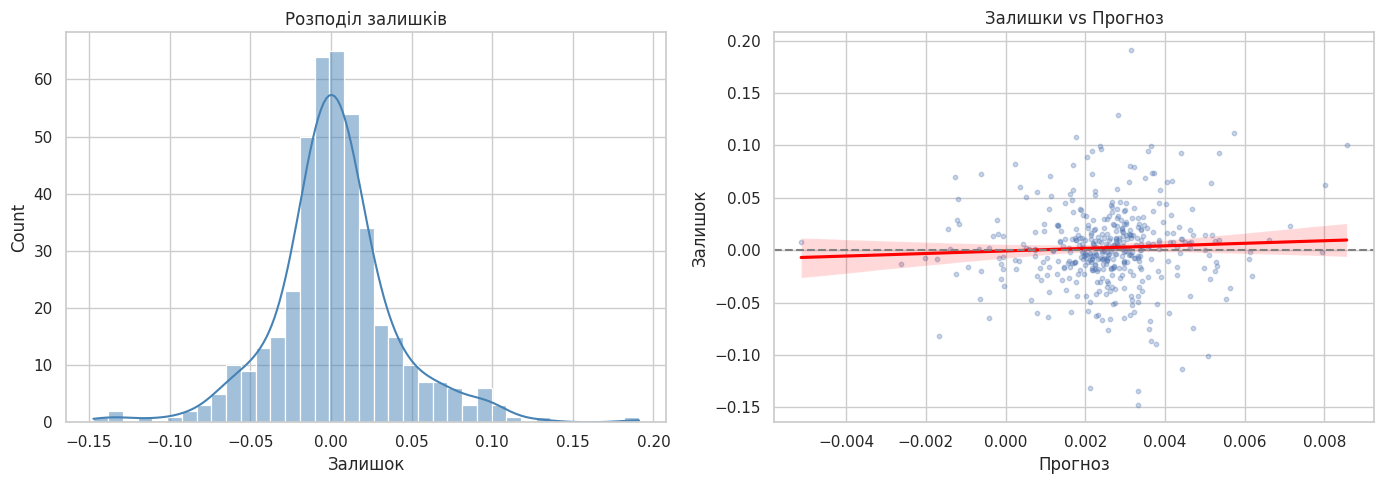

Середнє залишків: 0.002355
Std залишків: 0.037750


In [55]:
# функції діагностики залишків моделі засобами regplot
residuals = test["r_y"].values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Розподіл залишків
sns.histplot(residuals, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Розподіл залишків")
axes[0].set_xlabel("Залишок")

# Залишки vs прогноз
sns.regplot(x=y_pred, y=residuals, ax=axes[1],
            scatter_kws={"alpha": 0.3, "s": 10},
            line_kws={"color": "red"})
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_title("Залишки vs Прогноз")
axes[1].set_xlabel("Прогноз")
axes[1].set_ylabel("Залишок")

plt.tight_layout()
plt.show()

print(f"Середнє залишків: {residuals.mean():.6f}")
print(f"Std залишків: {residuals.std():.6f}")

## Висновки діагностики залишків

- Розподіл залишків близький до нормального з піком біля 0 — модель не має систематичного зміщення
- Середнє залишків ~0.0024 — майже нульове, модель не переоцінює і не недооцінює систематично
- Std залишків = 0.0378 — великий розкид підтверджує що модель не вловлює більшість коливань
- На графіку "Залишки vs Прогноз" немає чіткого патерну — залишки випадкові
- Лінійна модель є статистично коректною але практично малопотужною для Bitcoin

#  Загальні висновки: Модуль 4 — Часові ряди та сентимент-аналіз фінансових новин

## 1. Що аналізували
Історичні дані цін Bitcoin (2015-2021) та новини крипторинку. Мета — побудувати baseline модель прогнозування та дослідити текстовий контекст новин.

## 2. Ключові знахідки

- **Ціна Bitcoin зросла від $211 до $63,540** за 6 років — колосальна волатильність
- **Топ-слова новин**: crypto, cryptocurrency, exchange, blockchain, cash — фінансово-технічна тематика
- **R² = 0.0018** — проста лінійна модель не здатна прогнозувати доходності Bitcoin
- **Залишки нормально розподілені** — модель статистично коректна але практично слабка
- **Гіпотеза ефективного ринку підтверджується** — минулі ціни не передбачають майбутні

## 3. Обмеження даних

- Лише цінові дані без макроекономічних факторів
- Новини не використані як предиктори — лише описовий аналіз
- Лінійна модель є baseline — не відображає нелінійну природу крипторинку

## 4. Наступні кроки

- **LSTM/GRU**: нейромережі для прогнозування часових рядів
- **Сентимент-аналіз**: використати тональність новин як ознаку для моделі
- **ARIMA/Prophet**: класичні моделі часових рядів
- **Мультифакторна модель**: додати обсяг торгів, ринкову капіталізацію, індекс страху